 # Data Quality Summary: Critical Issues in Saudi Prescription Records

This report examines 816 prescription records and found several errors serious enough to affect patient care. Some patients have the wrong date of birth on file, causing their age to appear different from reality. Many patients are labeled as adults when they are children, or vice versa. Some prescriptions list medications in the wrong form — for example, a tablet recorded instead of a syrup. A small number of children under five have been prescribed medications considered unsafe for their age group. There are also duplicate prescriptions and records dated before the patient was even born. Until these errors are fixed, doctors, pharmacists, and auditors should treat this data with caution.

### Dataset Overview

In [ ]:
# Import important libraries

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_excel('EliteData.xlsx')

#### Dataset Structure

In [3]:
df.head()

,prescription_id,claim_id,patient_name,national_id,iqama_number,date_of_birth,age,gender,nationality,diagnosis_code,diagnosis_description,medication_name,dose_strength,dose_unit,quantity,frequency_per_day,duration_days,prescription_datetime,prescribing_physician,hospital_name,hospital_code,hospital_sector,region,approval_status,dispensing_status,patient_type,visit_type,notes,internal_ref_code,system_flag
0,PRX-83569939,CLM-620465-2025,Omar Al-Qahtani,1.653911e+09,NaN,2025-11-02,0,Male,Saudi,M79.3 | E03.9,Panniculitis,OMEPRAZOLE 20MG CAPSULES,20 MG,mg,28.0,2.0,21.0,2025-10-15 18:45:00,Dr. Saud Al-Hamdan,King Abdulaziz Hospital,MOH-02-012-0002,MOH,Jeddah,Approved,Not Dispensed,Pediatric,Inpatient,NaN,NaN,NaN
1,PRX-33645674,CLM-422998-2025,Asma Al-Sulami,1.083638e+09,NaN,1992-07-27,33,Female,Saudi,I10 | F32.9,Essential hypertension,SERTRALINE 50MG TABLETS,NaN,NaN,NaN,NaN,NaN,2025-10-15 21:20:00,Dr. Abdullah Al-Mutairi,King Fahad Hospital Dammam,MOH-04-031-0003,MOH,Dammam,Approved,Not Dispensed,Adult,Emergency,NaN,NaN,NaN
2,PRX-36851375,CLM-964169-2025,Ali Al-Yami,1.666421e+09,NaN,2007-05-06,18,Male,Saudi,H40.1,Open-angle glaucoma,LEVOTHYROXINE 50MCG TABLETS,50 MCG,mg,30.0,2.0,30.0,2025-10-15 17:31:00,Dr. Yazeed Al-Mutairi,Alhada Armed Forces Hospital,MOD-03-037-0030,MOD,Al-Taif,Approved,Not Dispensed,Adult,Inpatient,NaN,NaN,NaN
3,PRX-89503557,CLM-268956-2025,Nasser Al-Zahrani,1.517025e+09,NaN,1981-05-10,5,Male,Saudi,F32.9,Depressive episode,LEVOTHYROXINE 50MCG TABLETS,NaN,NaN,NaN,NaN,NaN,2025-10-15 20:01:00,Dr. Nasser Al-Anazi,King Abdulaziz Hospital,MOH-02-012-0002,MOH,Jeddah,Approved,Not Dispensed,Adult,Emergency,NaN,NaN,NaN
4,PRX-53309532,CLM-550244-2025,Turki Al-Ghamdi,2.271725e+09,2.730146e+09,1951-10-17,74,Male,Non-Saudi,M79.3,Panniculitis,SALBUTAMOL 100MCG INHALER,100 MCG,puff,500000.0,1.0,7.0,2025-10-15 18:25:00,Dr. Khaled Al-Zahrani,Al-Noor Specialist Hospital,MOH-05-021-0004,MOH,Makkah,Approved,Not Dispensed,Adult,Outpatient,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prescription_id        816 non-null    object 
 1   claim_id               816 non-null    object 
 2   patient_name           816 non-null    object 
 3   national_id            708 non-null    float64
 4   iqama_number           110 non-null    float64
 5   date_of_birth          816 non-null    object 
 6   age                    816 non-null    int64  
 7   gender                 816 non-null    object 
 8   nationality            816 non-null    object 
 9   diagnosis_code         816 non-null    object 
 10  diagnosis_description  816 non-null    object 
 11  medication_name        816 non-null    object 
 12  dose_strength          652 non-null    object 
 13  dose_unit              652 non-null    object 
 14  quantity               652 non-null    float64
 15  freque

The dataset that we have consists of 816 row, in addition to 30 column

In [5]:
# Understanding Statistical Relations Between Numerical Columns
df.describe()

,national_id,iqama_number,age,quantity,frequency_per_day,duration_days,internal_ref_code
count,7.080000e+02,1.100000e+02,816.000000,6.520000e+02,652.00000,652.000000,0.0
mean,1.645476e+09,2.590046e+09,42.181373,6.084561e+04,1.96319,20.277607,NaN
std,4.591176e+08,2.485334e+08,19.833019,4.509384e+05,0.81378,8.604714,NaN
min,1.001695e+09,2.100010e+09,0.000000,2.000000e+01,1.00000,7.000000,NaN
25%,1.300728e+09,2.381315e+09,27.000000,2.800000e+01,1.00000,14.000000,NaN
50%,1.595796e+09,2.649084e+09,43.000000,3.000000e+01,2.00000,21.000000,NaN
75%,1.836021e+09,2.782633e+09,58.250000,3.000000e+01,3.00000,28.000000,NaN
max,2.998751e+09,2.997335e+09,75.000000,4.200000e+06,3.00000,30.000000,NaN


## Data Format Validation and Column Relationships

In this step, I check the format and type of values in each column to ensure data consistency.  
I also explore potential relationships and trends between columns to understand patterns, detect anomalies, and identify any data quality issues that may affect analysis.

### prescription_id
Check all prescription_id values match the pattern 'PRX-XXXXXXXX' where X is a digit

In [ ]:
PRX_pattern = r'^PRX-\d{8}$'

valid_count = df['prescription_id'].astype(str).str.match(PRX_pattern).sum()
invalid_count = (~df['prescription_id'].astype(str).str.match(PRX_pattern)).sum()

print("Valid:", valid_count)
print("Invalid:", invalid_count)

Valid: 816
Invalid: 0


The prescription_id column has 100% valid values matching the pattern 'PRX-XXXXXXXX' where X is a digit. No data quality issues were found in this column.

In [7]:
# Checking for duplications based on prescription_id

duplicated_rows = df['prescription_id'].value_counts()[lambda x: x > 1]

for prescription_id in duplicated_rows.index:
    rows = df.query(f'prescription_id == "{prescription_id}"')
    are_duplicates = rows.duplicated(keep=False).all()
    print(f"Prescription ID: {prescription_id}, Are all rows identical: {are_duplicates}")

Prescription ID: PRX-33607235, Are all rows identical: True
Prescription ID: PRX-66779304, Are all rows identical: True
Prescription ID: PRX-47072327, Are all rows identical: True
Prescription ID: PRX-69682874, Are all rows identical: True
Prescription ID: PRX-75082169, Are all rows identical: True
Prescription ID: PRX-79873032, Are all rows identical: True
Prescription ID: PRX-24271532, Are all rows identical: True
Prescription ID: PRX-34406132, Are all rows identical: True
Prescription ID: PRX-81396350, Are all rows identical: True
Prescription ID: PRX-10438499, Are all rows identical: True
Prescription ID: PRX-65738565, Are all rows identical: True
Prescription ID: PRX-26299760, Are all rows identical: True
Prescription ID: PRX-26918765, Are all rows identical: True
Prescription ID: PRX-72959166, Are all rows identical: False
Prescription ID: PRX-81057233, Are all rows identical: True
Prescription ID: PRX-68939010, Are all rows identical: True


In [8]:
# Select the rows
rows = df.query('prescription_id == "PRX-72959166"')

# Compare while treating NaNs as equal
differences = ~(rows.fillna("##NULL##") == rows.iloc[0].fillna("##NULL##"))

# Get columns with at least one real difference
different_columns = differences.any()[differences.any()].index.tolist()

print("Columns that differ:", different_columns)

Columns that differ: ['prescription_datetime']


In [9]:
df.query('prescription_id == "PRX-72959166"')

,prescription_id,claim_id,patient_name,national_id,iqama_number,date_of_birth,age,gender,nationality,diagnosis_code,diagnosis_description,medication_name,dose_strength,dose_unit,quantity,frequency_per_day,duration_days,prescription_datetime,prescribing_physician,hospital_name,hospital_code,hospital_sector,region,approval_status,dispensing_status,patient_type,visit_type,notes,internal_ref_code,system_flag
516,PRX-72959166,CLM-224698-2025,Omar Al-Ghamdi,2.456131e+09,2.841760e+09,1994-08-18,31,Male,Non-Saudi,E11.9 | K21.0,Type 2 diabetes mellitus without complications,Atorvastatin 20mg,NaN,NaN,NaN,NaN,NaN,2025-10-15 08:50:00,Dr. Mohammed Al-Qahtani,King Fahad Medical City,MOH-01-001-0001,MOH,Riyadh,Approved,Not Dispensed,Pediatric,Emergency,NaN,NaN,NaN
590,PRX-72959166,CLM-224698-2025,Omar Al-Ghamdi,2.456131e+09,2.841760e+09,1994-08-18,31,Male,Non-Saudi,E11.9 | K21.0,Type 2 diabetes mellitus without complications,Atorvastatin 20mg,NaN,NaN,NaN,NaN,NaN,2019-09-28 00:00:00,Dr. Mohammed Al-Qahtani,King Fahad Medical City,MOH-01-001-0001,MOH,Riyadh,Approved,Not Dispensed,Pediatric,Emergency,NaN,NaN,NaN


For prescription PRX-72959166, there are two records that are identical except for `prescription_datetime`. This confusion may result from this uncertainty about which timestamp accurately represents the prescribing event. Prescription records have a unique constraint by the system.

### claim_id

Check all claim_id values match tha pattern 'CLM-XXXXXX-XXXX', where X is the digit

In [10]:
CLM_pattern = r'^CLM-\d{6}-\d{4}$'

valid_count = df['claim_id'].astype(str).str.match(CLM_pattern).sum()
invalid_count = (~df['claim_id'].astype(str).str.match(CLM_pattern)).sum()

print("Valid:", valid_count)
print("Invalid:", invalid_count)

Valid: 816
Invalid: 0


The Claim_id column has 100% valid values match the pattern 'CLM-XXXXXX-XXXX' where X is a digit.

### national_id

Check if the national id column has match the three rules:

1. **Rule 1:** If both `national_id` and `iqama_number` exist:
   - Both must start with '2'.
   - Both must be exactly 10 digits long.

2. **Rule 2:** If only `national_id` exists (no `iqama_number`):
   - `national_id` must start with '1'.
   - It must be exactly 10 digits long.

3. **Rule 3:** If `national_id` starts with '1':
   - `iqama_number` should not exist (citizens should not have an iqama number).

In [11]:
def id_to_str(series):
    return series.where(
        series.isna(),
        series.astype('Int64').astype(str).str.strip()  # Int64 supports NaN, regular int doesn't
    )

df['national_id_str'] = id_to_str(df['national_id'])
df['iqama_number_str'] = id_to_str(df['iqama_number'])


# Rule 1: If both national_id and iqama_number exist, both must start with '2' and be exactly 10 digits long
rule1_violations = df[
    df['national_id'].notna() & df['iqama_number'].notna() &
    (
        ~df['national_id_str'].str.startswith('2', na=False) |
        ~df['iqama_number_str'].str.startswith('2', na=False) |
        (df['national_id_str'].str.len().ne(10)) |
        (df['iqama_number_str'].str.len().ne(10))
    )
]

# Rule 2: If national_id exists and iqama_number is missing, national_id must start with '1' and be exactly 10 digits long
rule2_violations = df[
    df['national_id'].notna() & df['iqama_number'].isna() &
    (
        ~df['national_id_str'].str.startswith('1', na=False) |
        (df['national_id_str'].str.len().ne(10))
    )
]

# Rule 3: If national_id starts with '1', iqama_number must not exist (citizens should not have iqama_number)
rule3_violations = df[
    df['national_id'].notna() &
    df['national_id_str'].str.startswith('1', na=False) &
    df['iqama_number'].notna()
]

cols_to_show = ['prescription_id',  'patient_name',
                'national_id_str', 'iqama_number_str']

print("=" * 60)
print("Rule 1 Violations — Both IDs exist but invalid format")
print("Expected: both start with 2, both 10 digits")
print(f"Total: {rule1_violations.shape[0]}")
print(rule1_violations[cols_to_show])

print("\n" + "=" * 60)
print("Rule 2 Violations — National ID only, should start with 1, 10 digits")
print(f"Total: {rule2_violations.shape[0]}")
print(rule2_violations[cols_to_show])

print("\n" + "=" * 60)
print("Rule 3 Violations — National ID starts with 1 but Iqama exists")
print(f"Total: {rule3_violations.shape[0]}")
print(rule3_violations[cols_to_show])

print("\n" + "=" * 60)
all_violations = pd.concat([rule1_violations, rule2_violations, rule3_violations]).drop_duplicates()
print(f"Total unique violations across all rules: {all_violations.shape[0]}")

Rule 1 Violations — Both IDs exist but invalid format
Expected: both start with 2, both 10 digits
Total: 0
Empty DataFrame
Columns: [prescription_id, patient_name, national_id_str, iqama_number_str]
Index: []

Rule 2 Violations — National ID only, should start with 1, 10 digits
Total: 0
Empty DataFrame
Columns: [prescription_id, patient_name, national_id_str, iqama_number_str]
Index: []

Rule 3 Violations — National ID starts with 1 but Iqama exists
Total: 0
Empty DataFrame
Columns: [prescription_id, patient_name, national_id_str, iqama_number_str]
Index: []

Total unique violations across all rules: 0


All prescriptions pass the ID validation rules:

- **Rule 1:** Both `national_id` and `iqama_number` exist → correctly start with '2' and are 10 digits long.  
- **Rule 2:** Only `national_id` exists → correctly starts with '1' and is 10 digits long.  
- **Rule 3:** Citizens with `national_id` starting with '1' → no `iqama_number` present.  

### date_of_birth validation

Check for Incorrect Date of Birth Formats

Some entries in the date_of_birth column may not follow the standard YYYY-MM-DD format, which can cause errors in age calculation or reporting. This section converts all dates to strings, checks for any entries that do not match the expected format, and lists the prescription ID and patient name for any problematic records. This helps identify data issues that need correction before analysis.

In [ ]:
# Ensure date_of_birth is a string
df['dob_str'] = df['date_of_birth'].astype(str)

# Find invalid date_of_birth values (not in YYYY-MM-DD format)
invalid_dob = df[~df['dob_str'].str.match(r'^\d{4}-\d{2}-\d{2}$', na=False)]

# Columns to display
cols_to_show = ['prescription_id', 'patient_name']

# Print results
print("Rows with date_of_birth not in YYYY-MM-DD format:")
print(invalid_dob[cols_to_show])

Rows with date_of_birth not in YYYY-MM-DD format:
   prescription_id      patient_name
90    PRX-19295792  Fatima Al-Hamdan


1 record in the dataset has an invalid `date_of_birth` format, affecting Prescription ID PRX-19295792 for patient Fatima Al-Hamdan. This is a low-severity issue because it does not directly impact clinical decisions but may affect age calculations or reporting. The system should enforce the correct YYYY-MM-DD format during data entry to prevent such errors.

In [ ]:
# Verify Patient Age Consistency. This section checks whether the age recorded for each patient matches the actual age calculated from their date_of_birth.
    
from dateutil.relativedelta import relativedelta

# Ensure date_of_birth is datetime
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

# Calculate exact age using relativedelta
today = pd.Timestamp('today').date()

df['calculated_age'] = df['date_of_birth'].apply(
    lambda dob: relativedelta(today, dob.date()).years if pd.notna(dob) else pd.NA
)

# Allow ±1 tolerance to handle borderline cases
df['age_match'] = df.apply(
    lambda row: abs(row['age'] - row['calculated_age']) <= 1
    if pd.notna(row['calculated_age']) and pd.notna(row['age'])
    else False,
    axis=1
)

# Print mismatches
mismatched_rows = df[~df['age_match']]

print("Number of age mismatches:", mismatched_rows.shape[0])
print("\nMismatched rows:")
print(mismatched_rows[['patient_name', 'date_of_birth', 'age', 'calculated_age']])

Number of age mismatches: 40

Mismatched rows:
            patient_name date_of_birth  age  calculated_age
3      Nasser Al-Zahrani    1981-05-10    5              44
38        Dana Al-Shehri    1984-08-08   12              41
43        Dana Al-Ghamdi    1995-11-30   14              30
65      Ahmed Al-Zahrani    1970-05-20    1              55
98    Abdullah Al-Sulami    1994-06-02    5              31
107      Omar Al-Qahtani    1998-09-22    2              27
120         Ali Al-Sayed    1996-05-05    5              29
126    Bandar Al-Qahtani    1994-12-27   12              31
142       Lina Al-Sulami    1987-11-08   11              38
173      Sara Al-Zahrani    1968-03-11    6              57
177         Sara Al-Yami    1988-06-23    4              37
318     Salman Al-Otaibi    1997-06-13    7              28
329        Ali Al-Ghamdi    1988-07-06   10              37
333  Mohammed Al-Mutairi    1956-11-13    8              69
342      Rawan Al-Maliki    1955-06-28   15          

In [14]:
# List of prescription IDs with age mismatches
wrong_age_prescriptions = mismatched_rows['prescription_id'].tolist()

print("Prescription IDs with incorrect age:")
print(wrong_age_prescriptions)

Prescription IDs with incorrect age:
['PRX-89503557', 'PRX-85374852', 'PRX-18397164', 'PRX-35264294', 'PRX-92662979', 'PRX-44635469', 'PRX-48298018', 'PRX-25745913', 'PRX-59317149', 'PRX-86325036', 'PRX-66143368', 'PRX-37128906', 'PRX-97210510', 'PRX-93903841', 'PRX-16141035', 'PRX-25613685', 'PRX-82369824', 'PRX-69421007', 'PRX-18967731', 'PRX-78010697', 'PRX-44809916', 'PRX-43315361', 'PRX-47689614', 'PRX-54325475', 'PRX-65383843', 'PRX-79962130', 'PRX-88216040', 'PRX-88378721', 'PRX-45346140', 'PRX-21403835', 'PRX-43742830', 'PRX-39987280', 'PRX-84455942', 'PRX-43252079', 'PRX-35636468', 'PRX-73411827', 'PRX-50409241', 'PRX-41501680', 'PRX-86211608', 'PRX-96592295']


40 records in the dataset show a mismatch between the recorded patient age and the age calculated from the patient’s date of birth. This is a high-severity issue because incorrect age information can lead doctors or pharmacists to make inappropriate dosing decisions or clinical judgments. The system should automatically calculate age from the date of birth instead of allowing it to be entered manually, and these records should be reviewed for correction.

### age Validation 

In [ ]:
# check whether there are records where the date_of_birth is in the future, which is logically impossible and indicates data entry errors that need to be corrected.

today = pd.Timestamp('today').normalize()

df['dob_in_future'] = df['date_of_birth'] > today

future_dob_rows = df[df['dob_in_future']]

print("Number of patients with future date_of_birth:", future_dob_rows.shape[0])
print("\nRows with future date_of_birth:")
print(future_dob_rows[['patient_name', 'date_of_birth', 'age']])

# Select prescription IDs for patients with future date_of_birth
future_dob_prescriptions = future_dob_rows['prescription_id'].tolist()

print("-" * 60)
print("Prescription IDs with future date_of_birth:")
print(future_dob_prescriptions)

Number of patients with future date_of_birth: 9

Rows with future date_of_birth:
          patient_name date_of_birth  age
8       Reem Al-Hamdan    2026-04-22    0
116   Rawan Al-Rashidi    2026-03-29    0
123  Ghadeer Al-Hamdan    2026-04-19    0
271    Sara Al-Mutairi    2026-04-10    0
444     Reem Al-Ghamdi    2026-04-23    0
634    Reem Al-Qahtani    2026-04-07    0
692    Nasser Al-Sayed    2026-04-13    0
736  Ghadeer Al-Otaibi    2026-04-13    0
764     Asma Al-Sulami    2026-04-20    0
------------------------------------------------------------
Prescription IDs with future date_of_birth:
['PRX-28713077', 'PRX-79173614', 'PRX-12919231', 'PRX-33489813', 'PRX-76479831', 'PRX-96356711', 'PRX-44540283', 'PRX-24181143', 'PRX-81056927']


10 records in the dataset have a date_of_birth set in the future, which is invalid. This is considered low severity because it is unlikely to cause immediate clinical issues, but it can affect age calculations and reporting accuracy. The system should prevent future dates from being entered for date_of_birth to ensure data integrity automatically.

### nationality

In [16]:
df.nationality.value_counts()

nationality
Saudi        706
Non-Saudi    110
Name: count, dtype: int64

In [17]:
# Ensure diagnosis_code is string
df['diagnosis_code_str'] = df['diagnosis_code'].astype(str)

# Regex pattern for a single code: Letter (optional) + 2 digits (or 1-3 digits) + optional dot + optional digit
# From your examples, it seems codes like 'R05' (no letter+dot+digit) are valid too
single_code_pattern = r'^[A-Z]?\d{1,3}(\.\d)?$'

# Function to validate one diagnosis_code cell
def is_valid_diagnosis(code_str):
    # Split by '|' and strip spaces
    codes = [c.strip() for c in code_str.split('|')]
    # Check each code
    return all(pd.Series(codes).str.match(single_code_pattern))

# Apply validation
df['diagnosis_code_valid'] = df['diagnosis_code_str'].apply(is_valid_diagnosis)

# Show invalid rows
invalid_diagnosis = df[df['diagnosis_code_valid'] == False]

print("Number of invalid diagnosis_code:", invalid_diagnosis.shape[0])
print(invalid_diagnosis[['diagnosis_code']])

Number of invalid diagnosis_code: 0
Empty DataFrame
Columns: [diagnosis_code]
Index: []


No invalid diagnosis codes were found.  
All entries are correctly formatted and complete.

### medication_name validation

In [18]:
# Split from right into 3 parts
split_cols = df['medication_name'].str.rsplit(' ', n=2)

# Count number of parts in each row
df['parts_count'] = split_cols.str.len()

# Valid rows → exactly 3 parts
valid_rows = df[df['parts_count'] == 3]

# Invalid rows → not exactly 3 parts
invalid_rows = df[df['parts_count'] != 3]

# Print results
print("Total rows:", len(df))
print("Valid format rows:", len(valid_rows))
print("Invalid format rows:", len(invalid_rows))

# Show invalid rows if any
print("\nInvalid rows:")
print(invalid_rows['medication_name'])

Total rows: 816
Valid format rows: 807
Invalid format rows: 9

Invalid rows:
324    Atorvastatin 20mg
350    Atorvastatin 20mg
429    Atorvastatin 20mg
516    Atorvastatin 20mg
590    Atorvastatin 20mg
619      metformin 500mg
670    Atorvastatin 20mg
770    Atorvastatin 20mg
781      metformin 500mg
Name: medication_name, dtype: object


In [19]:
# Split from right into 3 parts
split_cols = df['medication_name'].str.rsplit(' ', n=2)

# Count number of parts in each row
df['parts_count'] = split_cols.str.len()

# Valid rows → exactly 3 parts
valid_rows = df[df['parts_count'] == 3]

# Invalid rows → not exactly 3 parts
invalid_rows = df[df['parts_count'] != 3]

# Print results
print("Total rows:", len(df))
print("Valid format rows:", len(valid_rows))
print("Invalid format rows:", len(invalid_rows))

# Show invalid rows with prescription_id and medication_name
print("\nInvalid rows with prescription IDs:")
print(invalid_rows[['prescription_id', 'medication_name']])

Total rows: 816
Valid format rows: 807
Invalid format rows: 9

Invalid rows with prescription IDs:
    prescription_id    medication_name
324    PRX-66187845  Atorvastatin 20mg
350    PRX-60421010  Atorvastatin 20mg
429    PRX-85603667  Atorvastatin 20mg
516    PRX-72959166  Atorvastatin 20mg
590    PRX-72959166  Atorvastatin 20mg
619    PRX-24919279    metformin 500mg
670    PRX-39987280  Atorvastatin 20mg
770    PRX-11582229  Atorvastatin 20mg
781    PRX-98384904    metformin 500mg


9 prescriptions in this dataset have invalid dosage forms in the `medication_name` column, affecting medications like Atorvastatin and Metformin. This is a medium-severity issue because these inconsistencies could cause misinterpretation by pharmacists or electronic systems, potentially leading to dispensing errors. The prescribing system should enforce standardized dosage form formats to prevent such inconsistencies.

In [20]:
# Check format of medication_name and extract dosage_form

split_cols = df['medication_name'].str.split(' ', n=2)

df['dosage_form'] = split_cols.str[2]

df['dosage_form'].value_counts()

dosage_form
TABLETS                467
CAPSULES               150
INHALER                101
FILM COATED TABLETS     73
FCT                      9
500MG                    4
MG Tab                   3
Name: count, dtype: int64


I first check the `medication_name` column to extract the **dosage form** of each medication.  
This allows us to identify specific forms (e.g., tablets, capsules, inhalers) and analyze prescription patterns.  

Next, I perform a **pediatric safety check**:  
Children under 5 years old may not safely take certain medications or dosage forms.  
We filter the dataset for patients **age ≤ 5** who have been prescribed potentially **restricted dosage forms**, such as:  
`TABLETS`, `CAPSULES`, `INHALER`, `FILM COATED TABLETS`, `FCT`, `500MG`, `MG Tab`.  

This check highlights **potentially risky prescriptions for young children** that need review.

In [21]:
from datetime import date
from dateutil.relativedelta import relativedelta
import pandas as pd

today = date.today()

restricted_dosage_forms = [
    'TABLETS', 'CAPSULES', 'INHALER', 
    'FILM COATED TABLETS', 'FCT', 
    '500MG', 'MG Tab'
]

def safe_calculate_age(dob):
    if pd.isna(dob):
        return pd.NA
    dob_date = dob.date()  
    if dob_date > today:   
        return pd.NA
    return relativedelta(today, dob_date).years

df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['calculated_age'] = df['date_of_birth'].apply(safe_calculate_age)

children_under5_risky = df[
    (df['calculated_age'] <= 5) & 
    (df['dosage_form'].isin(restricted_dosage_forms))
]

print("Number of children under 5 with risky medications:", children_under5_risky.shape[0])
print(children_under5_risky[['prescription_id', 'patient_name', 'calculated_age']])

Number of children under 5 with risky medications: 20
    prescription_id        patient_name calculated_age
0      PRX-83569939     Omar Al-Qahtani              0
10     PRX-86181117     Noura Al-Ghamdi              0
24     PRX-73070585    Majed Al-Zahrani              0
105    PRX-22799546    Shahad Al-Shehri              0
119    PRX-37568520      Asma Al-Sulami              0
172    PRX-31086112      Sara Al-Hamdan              0
195    PRX-22891308     Majed Al-Sulami              0
236    PRX-33160465     Turki Al-Hamdan              0
279    PRX-35633440    Salman Al-Hamdan              0
322    PRX-58974793  Abdullah Al-Otaibi              0
349    PRX-75082169      Omar Al-Maliki              0
381    PRX-90801586  Mohammed Al-Sulami              0
465    PRX-74743230     Faisal Al-Sayed              0
493    PRX-67162555       Reem Al-Sayed              0
576    PRX-85716426        Dana Al-Yami              0
601    PRX-82133102        Reem Al-Yami              0
630    PRX-

18 prescriptions in this dataset are for children under 5 years old receiving medications that may be unsuitable for their age. This is a high-severity issue because such dosage forms can pose serious health risks if swallowed or administered incorrectly. The prescribing system should enforce age-based dosage restrictions to prevent unsafe prescriptions for young children.



### dose_unit

In [22]:
df.dose_unit.value_counts()

dose_unit
mg      573
puff     79
Name: count, dtype: int64


Checking the `dose_unit` column to ensure that the units match the **expected dosage forms**:  

- **Solid forms** (`TABLETS`, `CAPSULES`, `FILM COATED TABLETS`, `FCT`) should have the unit **mg**.  
- **Inhalers** (`INHALER`) should have the unit **puff**.  


In [23]:
# Define dosage form groups
solid_forms = ['TABLETS', 'CAPSULES', 'FILM COATED TABLETS', 'FCT']
inhaler_forms = ['INHALER']

# Check for invalid dose units or missing values
solid_violations = df[
    (df['dosage_form'].isin(solid_forms)) & 
    ((df['dose_unit'].isna()) | (df['dose_unit'].str.lower() != 'mg'))
]

inhaler_violations = df[
    (df['dosage_form'].isin(inhaler_forms)) & 
    ((df['dose_unit'].isna()) | (df['dose_unit'].str.lower() != 'puff'))
]

# Combine all violations
violations = pd.concat([solid_violations, inhaler_violations])

# Display only relevant columns
print(violations['dose_unit'].sum())

0


**Result:** No Violation `dose_unit` values were found.

### quantity validation

In [24]:
df.quantity.describe()

count    6.520000e+02
mean     6.084561e+04
std      4.509384e+05
min      2.000000e+01
25%      2.800000e+01
50%      3.000000e+01
75%      3.000000e+01
max      4.200000e+06
Name: quantity, dtype: float64

As noticed from the descriptive statistics, the `quantity` column contains some very high values (up to 4,200,000)

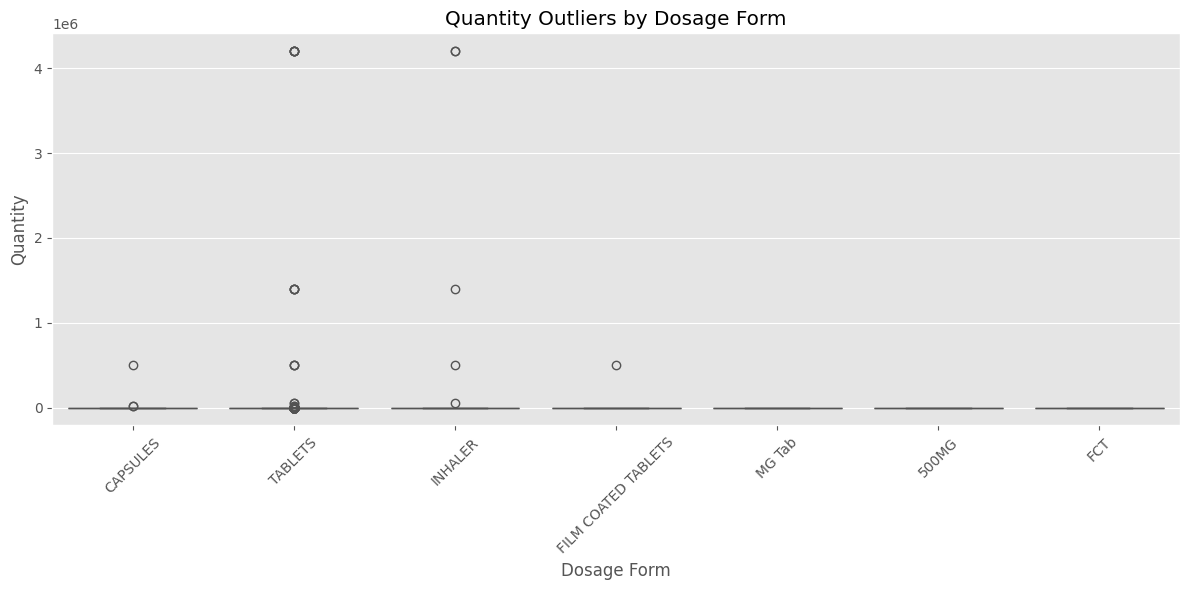

In [25]:
plt.figure(figsize=(12,6))

# Boxplot of quantity for each dosage form (outliers highlighted)
sns.boxplot(x='dosage_form', y='quantity', data=df, showfliers=True)

plt.xticks(rotation=45)
plt.title("Quantity Outliers by Dosage Form")
plt.ylabel("Quantity")
plt.xlabel("Dosage Form")
plt.tight_layout()
plt.show()


The plot shows **quantity outliers** across different dosage forms.  
Some forms, like TABLETS and INHALER, have unusually high quantities compared to the rest.

All records show inconsistent relationships between `dose_strength`, `dose_unit`, `quantity`, and `frequency_per_day`, where the combinations do not follow a clear or consistent dosing pattern. This relationship is unclear and difficult to understand. The prescribing system and data entry process should be reviewed to enforce standardized dosing rules and consistent unit usage.

### hospital_code validation

In [26]:
# Check if hospital code match hospital sector 

# Extract the first section of hospital_code
df['hospital_code_prefix'] = df['hospital_code'].str.split('-', n=1).str[0]

sector_mapping = {
    'MOH': 'MOH',
    'MOD': 'MOD',
    'PVT': 'PRIVATE',
    'NGHA': 'NGHA'
}

# Determine expected sector
df['expected_sector'] = df['hospital_code_prefix'].map(sector_mapping)

# Find mismatches
mismatched_sector = df[df['hospital_sector'] != df['expected_sector']]

# Print results
print("Rows with mismatched hospital_sector:")
print(mismatched_sector[['hospital_code', 'hospital_sector', 'expected_sector']])

Rows with mismatched hospital_sector:
Empty DataFrame
Columns: [hospital_code, hospital_sector, expected_sector]
Index: []


The hospital_sector matches the first part of hospital_code before the dash. 
This means the hospital sector data is consistent.

### approval_status

In [27]:
df.approval_status.value_counts()

approval_status
Approved    787
Rejected     29
Name: count, dtype: int64

### patient_type

In [28]:
age_threshold = 18

# Create expected patient_type based on calculated_age
df['expected_patient_type'] = df['calculated_age'].apply(
    lambda age: 'Adult' if pd.notna(age) and age >= age_threshold else 'Pediatric'
)

# Compare with the current patient_type
df['patient_type_valid'] = df['patient_type'] == df['expected_patient_type']

# Rows where patient_type is misclassified
mismatched_patient_type = df[~df['patient_type_valid']]

# Display the mismatches
print("Rows with mismatched patient_type based on age:")
print(mismatched_patient_type[['patient_name', 'calculated_age', 'patient_type', 'expected_patient_type']])
print("Number of mismatches:", mismatched_patient_type.shape[0])

Rows with mismatched patient_type based on age:
          patient_name calculated_age patient_type expected_patient_type
6      Sara Al-Qahtani             43    Pediatric                 Adult
7     Hessa Al-Rashidi             29    Pediatric                 Adult
10     Noura Al-Ghamdi              0        Adult             Pediatric
13      Sara Al-Hamdan             34    Pediatric                 Adult
14      Salman Al-Yami             22    Pediatric                 Adult
..                 ...            ...          ...                   ...
806     Sara Al-Hamdan             46    Pediatric                 Adult
808      Lama Al-Harbi             36    Pediatric                 Adult
809  Nasser Al-Zahrani             43    Pediatric                 Adult
811     Ali Al-Qahtani             27    Pediatric                 Adult
814    Majed Al-Shehri             32    Pediatric                 Adult

[414 rows x 4 columns]
Number of mismatches: 414


414 records in the dataset was missclassified. (e.g adults was classified as pediatric, and new born was classified as adults). This incorrect classification may cause high severity on patient, leading doctors to inappropriate dosing for treatment decisions.

The system should automatically derive patient_type from age or enforce validation rules to prevent incorrect classification during data entry.

### prescription_datetime validation

In [29]:
invalid_prescriptions = df[
    (df['prescription_datetime'] < df['date_of_birth']) &
    (df['date_of_birth'] < pd.Timestamp.today())
]

# Columns that clearly show the issue
cols_to_show = [
    'prescription_id',
    'prescription_datetime',
]

# Print them
print(invalid_prescriptions[cols_to_show])

# Print count
print("\nTotal invalid records:", invalid_prescriptions.shape[0])

    prescription_id prescription_datetime
0      PRX-83569939   2025-10-15 18:45:00
10     PRX-86181117   2025-10-15 17:10:00
24     PRX-73070585   2025-10-15 12:00:00
105    PRX-22799546   2025-10-15 22:11:00
119    PRX-37568520   2025-10-15 11:10:00
172    PRX-31086112   2025-10-15 20:41:00
195    PRX-22891308   2025-10-15 11:24:00
236    PRX-33160465   2025-10-15 21:06:00
279    PRX-35633440   2025-10-15 20:13:00
322    PRX-58974793   2025-10-15 07:33:00
349    PRX-75082169   2025-10-15 07:48:00
381    PRX-90801586   2025-10-15 08:01:00
465    PRX-74743230   2025-10-15 20:15:00
493    PRX-67162555   2025-10-15 08:59:00
576    PRX-85716426   2025-10-15 10:14:00
601    PRX-82133102   2025-10-15 19:49:00
630    PRX-75082169   2025-10-15 07:48:00
639    PRX-68230817   2025-10-15 19:09:00
718    PRX-45652586   2025-10-15 20:07:00
815    PRX-49945150   2025-10-15 15:35:00

Total invalid records: 20


20 prescriptions in this dataset have a prescription_datetime that occurs before the patient’s date_of_birth, which is logically impossible. This means the system records medications as being prescribed before the patient was born, making those records medically unreliable for doctors, pharmacists, or audits. The prescribing system should enforce a validation rule that prevents any prescription date earlier than the patient’s date of birth and these records should be investigated for data entry or system errors.